<a href="https://colab.research.google.com/github/amirshokhkhalimov-cmd/Computer_Vision/blob/main/pytorch0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
print(torch.__version__)

2.11.0+cpu


In [3]:
print("CUDA:"), torch.cuda.is_available()

CUDA:


(None, False)

In [4]:
scalar = torch.tensor(5)
print('scalar',scalar)

scalar tensor(5)


In [5]:
vector = torch.tensor([1,2,3]) # 1D
print('vector',vector)

vector tensor([1, 2, 3])


In [6]:
MATRIX = torch.tensor([[1,2,3,],
                       [4,5,6]]) # 2D
print('MATRIX',MATRIX)

MATRIX tensor([[1, 2, 3],
        [4, 5, 6]])


In [7]:
tensor3d = torch.stack([MATRIX,MATRIX + 10]) #3D
print("tensor 3d:", tensor3d)

tensor 3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])


In [8]:
random_numbers = torch.rand(2,3) # 0-1
print(random_numbers)
print(random_numbers.dtype)
print(random_numbers.device)

tensor([[0.4078, 0.4904, 0.3025],
        [0.4020, 0.9123, 0.2743]])
torch.float32
cpu


In [9]:

print(torch.zeros(3,3))

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [10]:
print(torch.ones(2,4))


tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [11]:
x = torch.tensor([[1,2],
                  [3,4]])
y = torch.tensor([[5,6],
                  [7,8]])
print(x+y)

tensor([[ 6,  8],
        [10, 12]])


In [12]:
x = torch.tensor([[1,2],
                  [3,4]])
y = torch.tensor([[5,6],
                  [7,8]])
print(x*y)

# Matrix multiplication
print(x@y)

tensor([[ 5, 12],
        [21, 32]])
tensor([[19, 22],
        [43, 50]])


In [13]:
# Import PyTorch and matplotlib
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks | nn module
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [14]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [15]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)  # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

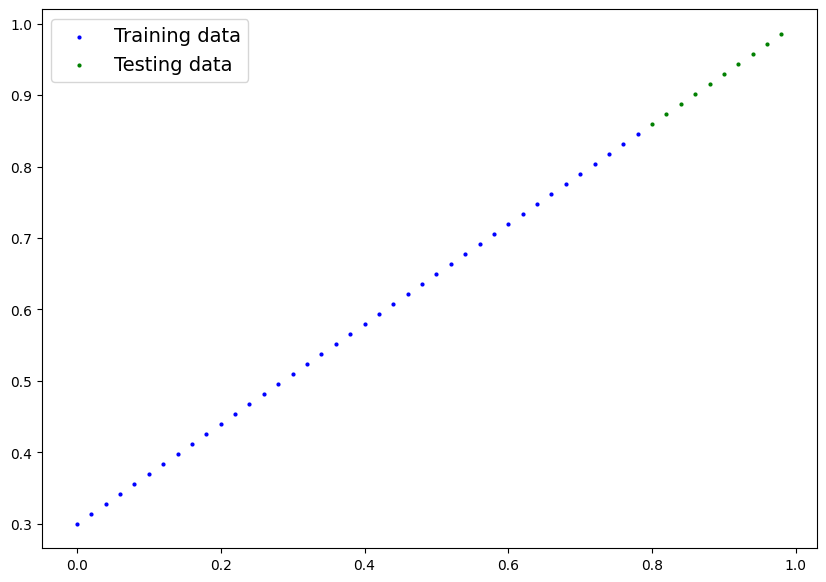

In [16]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

    plt.legend(prop={'size': 14})

plot_predictions()

In [17]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict(),

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [18]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),  # optimize newly created model's parameters
                            lr=0.01)

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

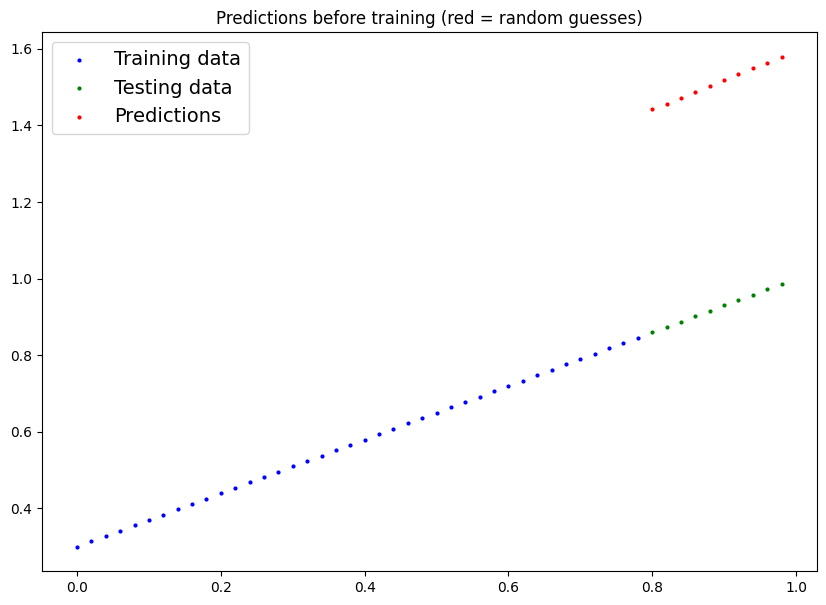

In [19]:
# See model's untrained predictions (on test set)
model_1.eval()
with torch.inference_mode():
    y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)
plt.title("Predictions before training (red = random guesses)")

In [20]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train()  # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradient optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()  # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch: 100 | Train loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch: 200 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 300 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 400 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 500 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 600 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 700 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 800 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch: 900 | Train loss: 0.0012645035749301314 | Test loss: 0.013801807537674904


In [21]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

Text(0.5, 1.0, 'Trained model predictions')

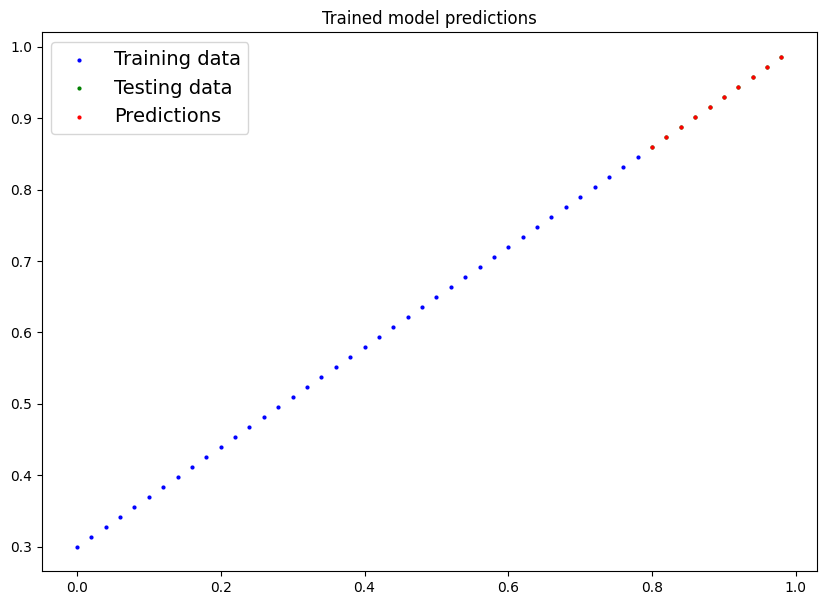

In [22]:
# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())
plt.title("Trained model predictions")

In [23]:
torch.save(model_1.state_dict(), "trained_model.pth")

In [24]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load("/content/trained_model.pth"))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)